In [1]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")


In [2]:
categories = {
    "국내주식": 145, "해외주식": 120, "채권": 85,
    "섹터": 95, "원자재": 25, "부동산": 15, "기타": 30,
}

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfon

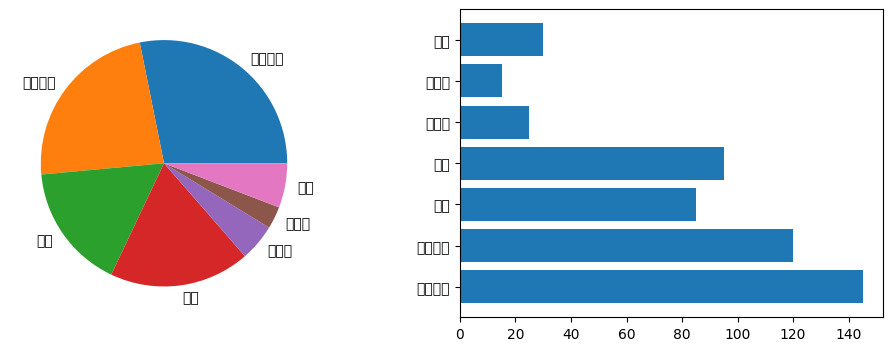

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.pie(categories.values(), labels = categories.keys(), )
ax2.barh(list(categories.keys()), list(categories.values()))

plt.show()

In [4]:
etf_universe = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]


In [5]:
df_etf = pd.DataFrame(etf_universe)
df_etf

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2
1,TIGER S&P500,해외주식,18.5,13.8
2,KODEX 배당가치,배당,8.2,10.5
3,TIGER 반도체,섹터,35.2,28.4
4,KODEX 국고채3년,채권,3.5,2.1
5,KODEX 골드선물,원자재,15.8,16.3
6,KODEX 2차전지,섹터,-5.2,32.1
7,TIGER 단기통안채,채권,3.2,0.8


In [6]:
df_etf['cat'].unique()

array(['국내주식', '해외주식', '배당', '섹터', '채권', '원자재'], dtype=object)

In [7]:
for _, row in df_etf[df_etf['cat']=='채권'].iterrows():
    print(row)

name      KODEX 국고채3년
cat                채권
ret_1y            3.5
risk              2.1
Name: 4, dtype: object
name      TIGER 단기통안채
cat                채권
ret_1y            3.2
risk              0.8
Name: 7, dtype: object


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.

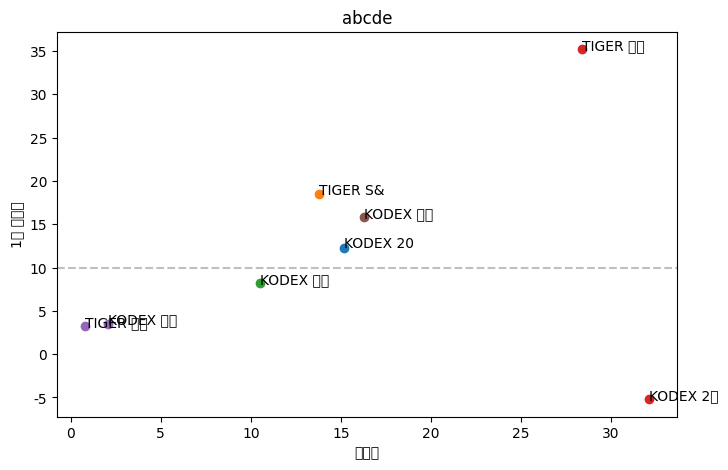

In [8]:
fig, ax = plt.subplots(figsize = (8,5))
for cat in df_etf['cat'].unique() :
    sub = df_etf[df_etf['cat']==cat]
    ax.scatter(sub['risk'], sub['ret_1y'], label = cat)
    for _, row in sub.iterrows():
        ax.annotate(row['name'][:8], (row['risk'], row['ret_1y']))

ax.set_xlabel('리스크')
ax.set_ylabel('1년 수익률')
ax.set_title('abcde')
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [9]:
# 데이터 스키마
# {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2}
# {'국내 주식', "12.3%", 20 

# dataclass

In [10]:
@dataclass
class ETFSchema: # def __init__
    ticker : str  # 00233439
    name : str
    category : str
    expense_ratio : float
    risk_level : str = "중간"
    aum_billion : float = 0.0
    description : str = ""
    keywords : List[str] = field(default_factory=list)

    def __post_init__(self):
        if self.expense_ratio < 0 or self.expense_ratio > 5:
            raise ValueError(f"수수료 범위 오류: {self.expense_ratio}")
        valid_risks = ["매우낮음", "낮음", "중간", "높음", "매우높음"]
        if self.risk_level not in valid_risks:
            raise ValueError(f"리스크 등급 오류: {self.risk_level}")  # "매우 낮음"

In [11]:
etf = ETFSchema(
    ticker = "069500", name="KODEX 200", category="국내주식", expense_ratio=1.5, keywords = ['코스피', '대형주', '인덱스'])

In [12]:
etf

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [13]:
etf.ticker, etf.name, etf.expense_ratio

('069500', 'KODEX 200', 1.5)

In [14]:
etf_dict = asdict(etf)

In [15]:
etf_dict

{'ticker': '069500',
 'name': 'KODEX 200',
 'category': '국내주식',
 'expense_ratio': 1.5,
 'risk_level': '중간',
 'aum_billion': 0.0,
 'description': '',
 'keywords': ['코스피', '대형주', '인덱스']}

In [16]:
etf_json = json.dumps(etf_dict, ensure_ascii=False, indent=2)
etf_json

'{\n  "ticker": "069500",\n  "name": "KODEX 200",\n  "category": "국내주식",\n  "expense_ratio": 1.5,\n  "risk_level": "중간",\n  "aum_billion": 0.0,\n  "description": "",\n  "keywords": [\n    "코스피",\n    "대형주",\n    "인덱스"\n  ]\n}'

In [17]:
ETFSchema(**json.loads(etf_json))

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [18]:
test_cases = [
    {"ticker": "A", "name": "정상", "category": "채권",
     "expense_ratio": 0.05, "risk_level": "낮음"},
    {"ticker": "B", "name": "수수료오류", "category": "주식",
     "expense_ratio": -0.5, "risk_level": "중간"},
    {"ticker": "C", "name": "리스크오류", "category": "원자재",
     "expense_ratio": 0.3, "risk_level": "최고"},
]

In [19]:
for tc in test_cases:
    try:
        e = ETFSchema(**tc)
        print(f" {tc['name']}: 생성 성공")
    except ValueError as err:
        print(f" {tc['name']} : {err}")

 정상: 생성 성공
 수수료오류 : 수수료 범위 오류: -0.5
 리스크오류 : 리스크 등급 오류: 최고


In [20]:
# ETFReturns : 데이터 스키마
# __post_init__ 수익률 유효성 검증 (-100% ~ 500%)
# ticker : str
# return_1m : float
# return_3m : float
# return_1y : float
# return_3y : float

In [21]:
@dataclass
class ETFReturns:
    ticker : str
    return_1m : float
    return_3m : float
    return_1y : float
    return_3y : float

    def __post_init__(self):
        # if self.return_1m < -100 or self.return_1m > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if self.return_3m < -100 or self.return_3m > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if self.return_1y < -100 or self.return_1y > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if getattr(self, 'return_1m') < -100 or getattr(self, 'return_1m') > 500:  # self.return_1m
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        for field_name in ['return_1m', 'return_3m', 'return_1y', 'return_3y']:
            value = getattr(self, field_name)
            if value < -100 or value > 500:
                raise ValueError(f"{field_name} 오류: {value}")

In [22]:
# ETFReturns("123456", -200.1, 5.4, 12.3, 28.5)

In [23]:
# FinanceDataReader

In [24]:
# !pip install finance-datareader

In [25]:
# StockListing('ETF/KR')
# DataReader('123456', start, end)

In [26]:
import FinanceDataReader as fdr

In [27]:
etf_list = fdr.StockListing('ETF/KR')

In [28]:
len(etf_list)

1093

In [29]:
etf_list.head(3)

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,94710,2,2045,2.21,94689.0,32.4893,15401829,1449982,218496
1,360750,4,TIGER 미국S&P500,25780,2,265,1.04,25695.0,0.8957,17095776,439893,159784
2,396500,2,TIGER 반도체TOP10,35935,2,445,1.25,36079.0,48.8674,13968697,498769,96809


In [30]:
ticker = "069500"
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

end_date, start_date

('2026-04-16', '2025-04-16')

In [31]:
price_df = fdr.DataReader(ticker, start_date, end_date)

In [32]:
len(price_df)

244

In [33]:
def collect_etf_price(ticker, days=365):
    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')

    try:
        df = fdr.DataReader(ticker, start_date, end_date)
        if len(df) > 0:
            return {'status' : 'real', 'data' : df, 'ticker' : ticker}
    except Exception:
        pass

In [34]:
tickers = ['069500']
collect_etf_price(tickers[0])

{'status': 'real',
 'data':              Open   High    Low  Close    Volume    Change
 Date                                                      
 2025-04-16  32556  32614  32169  32183   7177604 -0.015570
 2025-04-17  32271  32561  32203  32501   6951765  0.009881
 2025-04-18  32556  32722  32452  32722   6025639  0.006800
 2025-04-21  32727  32918  32634  32766   5020620  0.001345
 2025-04-22  32604  32824  32594  32658   5779669 -0.003296
 ...           ...    ...    ...    ...       ...       ...
 2026-04-10  88795  89805  88520  88655  12112242  0.016103
 2026-04-13  86465  88090  86410  87880  13658534 -0.008742
 2026-04-14  90245  91600  89955  90430  17031936  0.029017
 2026-04-15  93405  94180  92205  92665  22556415  0.024715
 2026-04-16  93460  94755  93035  94710  15401829  0.022069
 
 [244 rows x 6 columns],
 'ticker': '069500'}

In [35]:
# 결측치 처리, 이상치 처리

In [36]:
# # 주말, 휴장일, : row 전체가 결측치  / row 일부가 결측치
# 1. 무시 : 결측치 있는 값을 지워버린다
# 2. 채운다 : 

In [37]:
# 4/14 : 32570
# 4/15 :  채워준다. : interpolation : 평균 / 이전일 또는 이후일의 값 / rolling-average
# 4/16 : 32614

In [38]:
# outlier , anomaly , 이상치
# IQR : anomaly detect -> 지워버리거나 / 

In [39]:
sample_df = price_df.copy()

In [40]:
mask = np.random.random(len(sample_df)) < 0.05

In [41]:
sample_df.loc[mask, 'Close'] = np.nan

In [42]:
sample_df['Close'].isna().sum()

np.int64(9)

In [43]:
len(sample_df)

244

In [44]:
ffill_df = sample_df.copy()
ffill_df['Close'] = ffill_df['Close'].ffill()

In [45]:
ffill_df['Close'].isna().sum()

np.int64(0)

In [46]:
interp_df = sample_df.copy()
interp_df['Close'].isna().sum()

np.int64(9)

In [47]:
interp_df['Close'] = interp_df['Close'].interpolate(method='linear')

In [48]:
interp_df['Close'].isna().sum()

np.int64(0)

In [49]:
rolling_df = sample_df.copy()
rolling_mean = rolling_df['Close'].rolling(5, min_periods=1).mean()
rolling_mean
rolling_df['Close'] = rolling_df['Close'].fillna(rolling_mean)

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

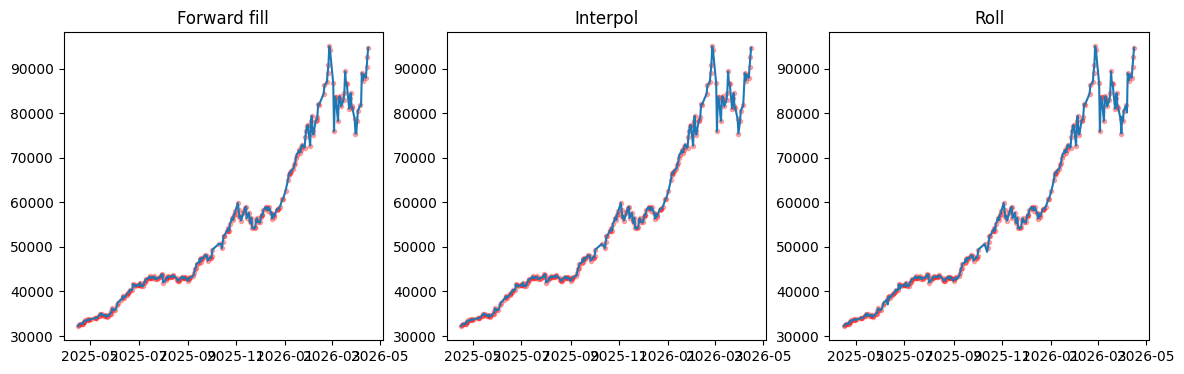

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df_filled, title in zip(axes, [ffill_df,interp_df, rolling_df], ['Forward fill', 'Interpol', 'Roll']):
    ax.plot(sample_df.index, sample_df['Close'], 'ro', markersize=3, alpha=0.3, label='missing')
    ax.plot(df_filled.index, df_filled['Close'], label=title)
    ax.set_title(title)
plt.show()

In [51]:
def detect_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

def detect_z(series, threshold=3.0):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold


z_outliers = detect_z(ffill_df)
z_outliers.sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [52]:
iqr_outliers = detect_iqr(ffill_df)
iqr_outliers.sum()

Open       0
High       0
Low        0
Close      0
Volume    10
Change    22
dtype: int64

In [53]:
(z_outliers & iqr_outliers).sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [54]:
ffill_df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-16,32556,32614,32169,32183.0,7177604,-0.015570
2025-04-17,32271,32561,32203,32501.0,6951765,0.009881
2025-04-18,32556,32722,32452,32722.0,6025639,0.006800
2025-04-21,32727,32918,32634,32766.0,5020620,0.001345
2025-04-22,32604,32824,32594,32658.0,5779669,-0.003296


In [55]:
features = ffill_df[['Close']].copy()

In [56]:
features

,Close
Date,
2025-04-16,32183.0
2025-04-17,32501.0
2025-04-18,32722.0
2025-04-21,32766.0
2025-04-22,32658.0
...,...
2026-04-10,88655.0
2026-04-13,87880.0
2026-04-14,90430.0


In [57]:
features['return'] = features['Close'].pct_change()

In [58]:
features.head()

,Close,return
Date,,
2025-04-16,32183.0,NaN
2025-04-17,32501.0,0.009881
2025-04-18,32722.0,0.006800
2025-04-21,32766.0,0.001345
2025-04-22,32658.0,-0.003296


In [59]:
features['vol_5d'] = features['return'].rolling(5).std()
features['vol_20d'] = features['return'].rolling(20).std()

In [60]:
features.head()

,Close,return,vol_5d,vol_20d
Date,,,,
2025-04-16,32183.0,NaN,NaN,NaN
2025-04-17,32501.0,0.009881,NaN,NaN
2025-04-18,32722.0,0.006800,NaN,NaN
2025-04-21,32766.0,0.001345,NaN,NaN
2025-04-22,32658.0,-0.003296,NaN,NaN


In [61]:
features['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

In [62]:
def preprocess_pipeline(df):
    result = df[['Close']].copy()

    #1. 결측값을 처리 (linear- interpolation)
    result['Close'] = result['Close'].interpolate(method='linear')
    result['Close'] = result['Close'].ffill().bfill()

    #2. 이상치를 ffill (IQR * 1.5)
    ret = result['Close']
    q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
    iqr = q3 - q1
    outlier_mask  = (ret < q1 - 1.5 * iqr) | (ret > q3 + 1.5 * iqr)
    result.loc[outlier_mask, 'Close'] = np.nan
    result['Close'] = result['Close'].ffill()

    #3. feature 추가 (return, log_return)
    result['return'] = result['Close'].pct_change()
    result['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

    return result
    

In [63]:
processed = preprocess_pipeline(price_df)

In [64]:
processed.head()

,Close,return,log_return
Date,,,
2025-04-16,32183.0,NaN,NaN
2025-04-17,32501.0,0.009881,0.009832
2025-04-18,32722.0,0.006800,0.006777
2025-04-21,32766.0,0.001345,0.001344
2025-04-22,32658.0,-0.003296,-0.003302


In [65]:
# 이동평균, 트렌드 분해(decomposition), 이상 탐지, 분포 분석
# 서버 트래픽, 이커머스 구매내역, 센서 데이터, 온도,,,,,

In [66]:
# 이동평균 : 노이즈
# S(standard)MA : 최근 N개의 평균
# E(exponential)MA : 최근 값에 더 큰 가중치를 두는 MA

In [67]:
# 트렌드 분해(decomposition)
# 트렌드 : 장기적으로 매출이 상승하고 있다. 전반적으로 시니어 타겟의 시장이 커지고 있다.
# Seasonality (주기) : 여름에는 잘팔리고, 겨울에는 안팔린다
# Residual (잔차) : 나머지

In [68]:
# !pip install statsmodels

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [70]:
ffill_df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-16,32556,32614,32169,32183.0,7177604,-0.015570
2025-04-17,32271,32561,32203,32501.0,6951765,0.009881
2025-04-18,32556,32722,32452,32722.0,6025639,0.006800
2025-04-21,32727,32918,32634,32766.0,5020620,0.001345
2025-04-22,32604,32824,32594,32658.0,5779669,-0.003296


In [71]:
close = ffill_df['Close']
close

Date
2025-04-16    32183.0
2025-04-17    32501.0
2025-04-18    32722.0
2025-04-21    32766.0
2025-04-22    32658.0
               ...   
2026-04-10    88655.0
2026-04-13    87880.0
2026-04-14    90430.0
2026-04-15    92665.0
2026-04-16    94710.0
Name: Close, Length: 244, dtype: float64

In [72]:
sma_20 = close.rolling(20).mean()
ema_20 = close.ewm(span=20).mean() 

In [73]:
weekly = close.resample('W').last().dropna()
decomp = seasonal_decompose(weekly, model = 'additive', period=13)

In [74]:
# decomp.seasonal

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

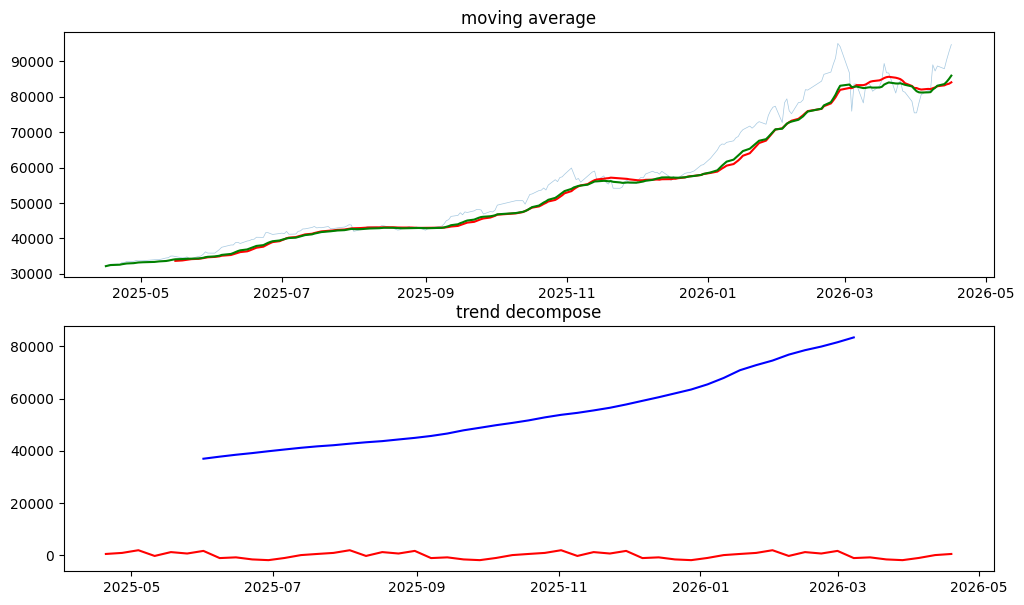

In [75]:
fig, axes = plt.subplots(2, 1, figsize = (12, 7))
ax = axes[0]
ax.plot(close.index, close, alpha=0.4, linewidth=0.5, label='original')
ax.plot(sma_20.index, sma_20, linewidth=1.5, label = 'sma', color='red')
ax.plot(ema_20.index, ema_20, linewidth=1.5, label = 'ema', color='green')
ax.set_title('moving average')

weekly = close.resample('W').last().dropna()
decomp = seasonal_decompose(weekly, model = 'additive', period=13)
axes[1].plot(decomp.trend.index, decomp.trend, label='trend', linewidth=1.5, color= 'blue')
axes[1].plot(decomp.seasonal.index, decomp.seasonal, label='seasonal', linewidth=1.5, color='red')
axes[1].set_title('trend decompose')

plt.show()

In [76]:
# time-series data : trend + seasonality + (residual)
#                    trend * seasonality + (residual)

In [77]:
tickers = {
    '069500': 'KODEX 200 (국내주식)',
    '360750': 'TIGER S&P500 (미국주식)',
    '152380': 'KODEX 국고채10년 (채권)',
    '132030': 'KODEX 골드선물 (원자재)',
}


In [78]:
multi_close = pd.DataFrame()
for ticker, name in tickers.items():
    df = fdr.DataReader(ticker, start=(datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d'))
    multi_close[name] = df['Close']

In [79]:
multi_close.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,32183,18720,70899,19582
2025-04-17,32501,18616,70860,19806
2025-04-18,32722,18621,70993,19851
2025-04-21,32766,18334,71127,20135
2025-04-22,32658,18161,71048,20707


In [80]:
multi_close = multi_close.dropna()

In [81]:
returns = multi_close.pct_change().dropna()

In [82]:
returns.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-17,0.009881,-0.005556,-0.000550,0.011439
2025-04-18,0.006800,0.000269,0.001877,0.002272
2025-04-21,0.001345,-0.015413,0.001888,0.014307
2025-04-22,-0.003296,-0.009436,-0.001111,0.028408
2025-04-23,0.018035,0.036121,0.001379,-0.047327


In [83]:
cum_returns = (1 + returns).cumprod()


In [84]:
cum_returns.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-17,1.009881,0.994444,0.999450,1.011439
2025-04-18,1.016748,0.994712,1.001326,1.013737
2025-04-21,1.018115,0.979380,1.003216,1.028240
2025-04-22,1.014759,0.970139,1.002102,1.057451
2025-04-23,1.033061,1.005182,1.003484,1.007405


In [85]:
cum_returns.tail()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2026-04-10,2.754715,1.341079,0.946699,1.380094
2026-04-13,2.730634,1.338942,0.944301,1.372179
2026-04-14,2.809869,1.353098,0.949379,1.382647
2026-04-15,2.879315,1.362981,0.950789,1.397457
2026-04-16,2.942858,1.377137,0.947898,1.396946


In [86]:
cum_returns.columns

Index(['KODEX 200 (국내주식)', 'TIGER S&P500 (미국주식)', 'KODEX 국고채10년 (채권)',
       'KODEX 골드선물 (원자재)'],
      dtype='object')

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/Users/jeongi

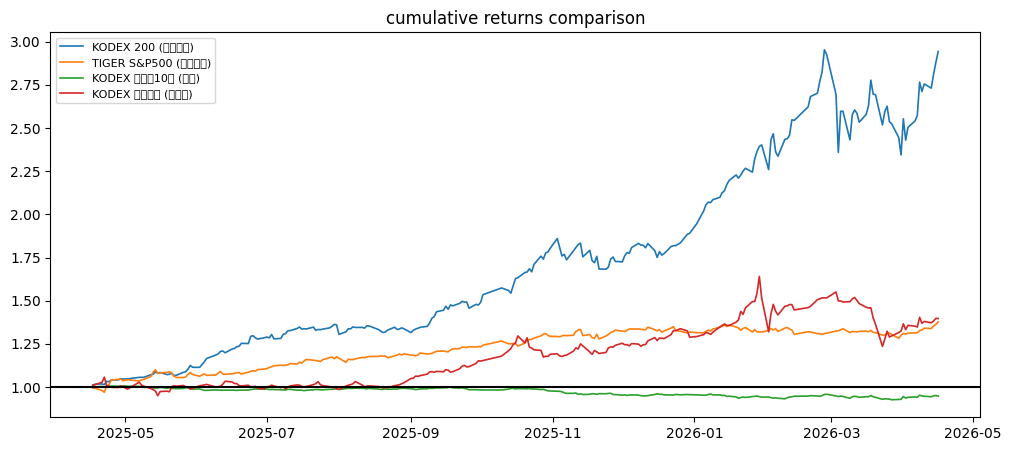

In [87]:
fig, ax = plt.subplots(figsize =  (12, 5))
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], label=col, linewidth = 1.2)

ax.axhline(1.0, color='black')
ax.legend(fontsize=8)
ax.set_title('cumulative returns comparison')
plt.show()

In [88]:
# pearson correlation (피어슨 상관관계)

In [89]:
corr_matrix = returns.corr()

In [90]:
corr_matrix

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
KODEX 200 (국내주식),1.000000,0.291863,0.389110,0.387167
TIGER S&P500 (미국주식),0.291863,1.000000,0.032967,-0.062498
KODEX 국고채10년 (채권),0.389110,0.032967,1.000000,0.163518
KODEX 골드선물 (원자재),0.387167,-0.062498,0.163518,1.000000


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45380 (\N{HANGUL SYLL

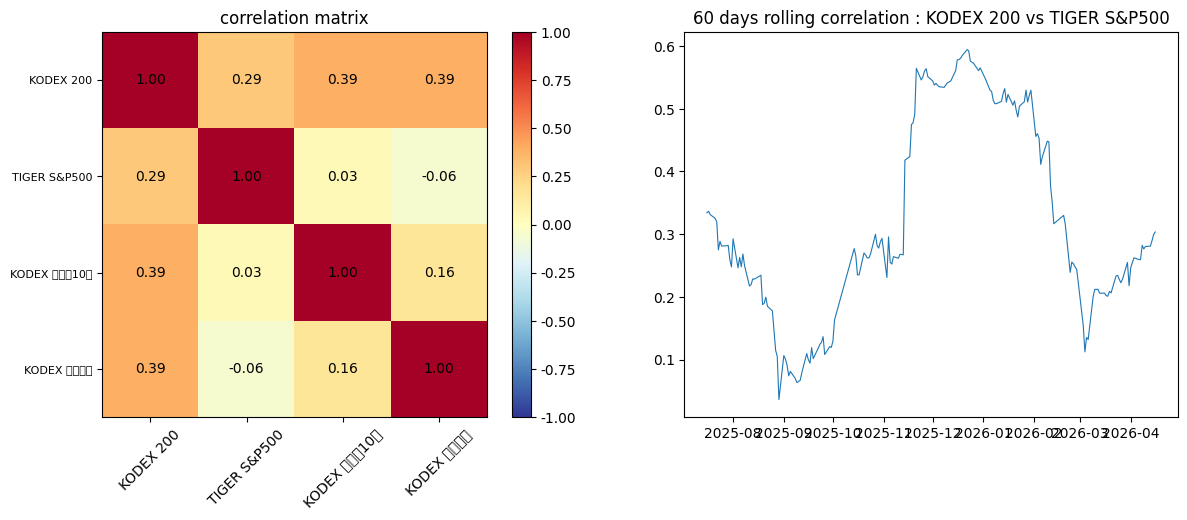

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
im = ax1.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)  # 히트맵
ax1.set_xticks(range(len(corr_matrix)))
ax1.set_yticks(range(len(corr_matrix)))
short_names = [c.split('(')[0].strip() for c in corr_matrix.columns]
ax1.set_xticklabels(short_names, rotation=45)
ax1.set_yticklabels(short_names, fontsize=8)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax1.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', fontsize=10, ha='center', va='center')
fig.colorbar(im, ax= ax1)
ax1.set_title('correlation matrix')

cols = returns.columns.tolist()
if len(cols) >=2:
    rolling_corr = returns[cols[0]].rolling(60).corr(returns[cols[1]])
    ax2.plot(rolling_corr.index, rolling_corr, linewidth=0.8)
    ax2.set_title(f'60 days rolling correlation : {short_names[0]} vs {short_names[1]}')

plt.show()

In [92]:
def calculate_metrics(returns_series, risk_free = 0.035): # 수익률, 변동성, MDD, 샤프
    ann_ret = (1 + returns_series.mean()) ** 252 - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_ret - risk_free) / ann_vol
    
    cum = (1 + returns_series).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    
    return {
        'yearly return' : f'{ann_ret* 100 :.1f}%',
        'yearly volatile' : f'{ann_vol* 100 :.1f}%',
        'MDD' : f'{mdd * 100:.1f}%',
        'sharpe' : f'{sharpe:.1f}'
    }

In [93]:
metrics_rows = []
for col in returns.columns:
    m = calculate_metrics(returns[col])
    m['ETF'] = col.split('(')[0].strip()
    metrics_rows.append(m)

In [94]:
metrics_rows

[{'yearly return': '227.4%',
  'yearly volatile': '36.6%',
  'MDD': '-20.6%',
  'sharpe': '6.1',
  'ETF': 'KODEX 200'},
 {'yearly return': '40.6%',
  'yearly volatile': '13.3%',
  'MDD': '-5.7%',
  'sharpe': '2.8',
  'ETF': 'TIGER S&P500'},
 {'yearly return': '-5.2%',
  'yearly volatile': '5.7%',
  'MDD': '-8.0%',
  'sharpe': '-1.5',
  'ETF': 'KODEX 국고채10년'},
 {'yearly return': '48.5%',
  'yearly volatile': '31.0%',
  'MDD': '-24.7%',
  'sharpe': '1.5',
  'ETF': 'KODEX 골드선물'}]

In [95]:
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,yearly return,yearly volatile,MDD,sharpe,ETF
0,227.4%,36.6%,-20.6%,6.1,KODEX 200
1,40.6%,13.3%,-5.7%,2.8,TIGER S&P500
2,-5.2%,5.7%,-8.0%,-1.5,KODEX 국고채10년
3,48.5%,31.0%,-24.7%,1.5,KODEX 골드선물


In [96]:
metrics_df = pd.DataFrame(metrics_rows).set_index('ETF')
metrics_df

,yearly return,yearly volatile,MDD,sharpe
ETF,,,,
KODEX 200,227.4%,36.6%,-20.6%,6.1
TIGER S&P500,40.6%,13.3%,-5.7%,2.8
KODEX 국고채10년,-5.2%,5.7%,-8.0%,-1.5
KODEX 골드선물,48.5%,31.0%,-24.7%,1.5


In [97]:
print(metrics_df)

             yearly return yearly volatile     MDD sharpe
ETF                                                      
KODEX 200           227.4%           36.6%  -20.6%    6.1
TIGER S&P500         40.6%           13.3%   -5.7%    2.8
KODEX 국고채10년         -5.2%            5.7%   -8.0%   -1.5
KODEX 골드선물           48.5%           31.0%  -24.7%    1.5


In [98]:
metrics_df.to_string()

'             yearly return yearly volatile     MDD sharpe\nETF                                                      \nKODEX 200           227.4%           36.6%  -20.6%    6.1\nTIGER S&P500         40.6%           13.3%   -5.7%    2.8\nKODEX 국고채10년         -5.2%            5.7%   -8.0%   -1.5\nKODEX 골드선물           48.5%           31.0%  -24.7%    1.5'

In [99]:
# 금융챗봇 
# 1. 데이터 수집, 전처리
# 2. 데이터 분석 
# ---------------------- raw data
# 3. 데이터 만들기        : RAG --> 사용자 쿼리 : RAG 성능 평가를 위한 데이터 생성
# 4. RAG 구현

In [100]:
def generate_analysis_insight(metrics_df):
    response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.3, max_tokens=400).invoke([
        {'role' : 'system', 'content' : '당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다'},
        {'role' : 'user', 'content' : f"""아래 ETF 비교 데이터를 분석하여 투자 인사이트를 작성하세요.
        
        {metrics_df.to_string()}
        
        다음 형식으로 답하세요:
        1. 핵심 발견(3줄)
        2. 위험 요인(2줄)
        3. 분산 투자 제안(2줄)"""}
    ])
    return response.content

In [101]:
insight = generate_analysis_insight(metrics_df)


In [102]:
print(insight)

1. 핵심 발견: KODEX 200은 가장 높은 연간 수익률(227.4%)과 샤프 비율(6.1)을 기록하여 뛰어난 성과를 보였습니다. TIGER S&P500도 안정적인 수익률(40.6%)을 제공하며 낮은 변동성을 유지하고 있습니다. 반면, KODEX 국고채10년은 부정적인 수익률(-5.2%)을 기록하여 투자 매력이 떨어집니다.

2. 위험 요인: KODEX 200은 높은 수익률에도 불구하고 연간 변동성이 36.6%로 상당히 높아 시장의 급격한 변동에 취약할 수 있습니다. KODEX 골드선물은 높은 변동성(31.0%)과 함께 큰 최대 낙폭(-24.7%)을 보여 리스크가 큽니다.

3. 분산 투자 제안: KODEX 200과 TIGER S&P500을 조합하여 높은 수익률과 안정성을 동시에 추구하는 것이 좋습니다. 또한, KODEX 국고채10년과 KODEX 골드선물을 소량 포함시켜 포트폴리오의 리스크를 분산시키는 전략을 고려할 수 있습니다.


In [103]:
# !pip install scipy

In [104]:
def generate_analysis_report(ticker_name, close_prices):
    
    returns = close_prices.pct_change().dropna()
    sma_20 = close_prices.rolling(20).mean().iloc[-1]
    sma_60 = close_prices.rolling(60).mean().iloc[-1]
    current = close_prices.iloc[-1]
    
    roll_mean = returns.rolling(30).mean()
    roll_std = returns.rolling(30).std()
    z_latest = ((returns - roll_mean) / roll_std).iloc[-1]
    
    from scipy.stats import skew, kurtosis
    
    sk = skew(returns.dropna())
    kt = kurtosis(returns.dropna())
    
    vol_recent = returns[-20:].std() * np.sqrt(252) * 100
    vol_overall = returns.std() * np.sqrt(252) * 100
    
    indicators = {
        '현재가': f'{current:,.0f}',
        'SMA(20)': f'{sma_20:,.0f}',
        'SMA(60)': f'{sma_60:,.0f}',
        '추세': '상승' if sma_20 > sma_60 else '하락',
        '최근 롤링 Z-score': f'{z_latest:.2f}',
        '이상 여부': '정상' if abs(z_latest) < 2 else '주의' if abs(z_latest) < 3 else '이상',
        'Skewness': f'{sk:.3f}',
        'Kurtosis': f'{kt:.3f}',
        '최근 20일 변동성': f'{vol_recent:.1f}%',
        '전체 변동성': f'{vol_overall:.1f}%',
        '변동성 변화': '확대' if vol_recent > vol_overall else '축소',
    }
    
    response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.5, max_tokens=400).invoke([
        {'role' : 'system', 'content' : '당신은 데이터 분석가입니다. 수치에 근거해서 분석하세요'},
        {'role' : 'user', 'content' : f"""이 시계열 분석 지표를 바탕으로 {ticker_name}의 현재 상태를 2~3문장으로 요약해주세요
         
         {json.dumps(indicators, ensure_ascii=False, indent=2)}
         
         투자 추천은 하지 마세요. 객관적 현황만 서술해주세요."""}
    ])
    
    
    return response.content
    

In [105]:
generate_analysis_report('KODEX 200', close)

'현재 KODEX 200의 주가는 94,710으로, 20일 이동평균선(SMA 20)인 84,046과 60일 이동평균선(SMA 60)인 81,823을 상회하며 상승 추세를 보이고 있습니다. 최근 롤링 Z-score는 0.50으로 정상 범위에 있으며, 변동성은 최근 20일 기준 53.7%로 확대되고 있습니다. Skewness는 -0.699로 약간의 왼쪽 비대칭을 나타내고, Kurtosis는 7.229로 높은 피크를 보여 데이터의 분포가 뾰족함을 시사합니다.'

In [106]:
def generate_analysis_report_llm_only(ticker_name, close_prices):
    recent_prices = close_prices.tail(120).tolist()
    
    prompt = f"""
    다음은 {ticker_name}의 종가 데이터입니다.
    
    {recent_prices}
    
    이 데이터를 기반으로 
    - 추세 (상승/하락/횡보)
    - 변동성 특징
    - 최근 이상 움직임 여부
    
    를 판단하고 2~3문장으로 요약하세요.
    
    수치 계산은 직접 수행해서 근거 기반으로 설명하세요.
    투자 추천은 하지 마세요. 객관적 현황만 서술해주세요."""
    
    response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.5, max_tokens=400).invoke([
        {'role' : 'system', 'content' : '당신은 데이터 분석가입니다. 수치에 근거해서 분석하세요'},
        {'role' : 'user', 'content' : prompt}
    ])
    
    return response.content


generate_analysis_report_llm_only('KODEX 200', close)

'주어진 KODEX 200의 종가 데이터를 분석한 결과는 다음과 같습니다.\n\n1. **추세**: 전체적으로 종가는 상승세를 보이고 있으며, 특히 2020년 중반부터 2021년 초까지의 구간에서 급격한 상승이 있었습니다. 이후 2021년 중반부터 2022년 초까지는 조정세를 보였으나, 다시 상승세로 돌아섰습니다.\n\n2. **변동성 특징**: 종가의 표준편차를 계산해보면 약 4,500의 변동성을 나타내어, 상대적으로 큰 변동성을 가진 것으로 평가됩니다. 특히, 최근 2022년 하반기와 2023년 초반에 급격한 가격 변화가 있었음을 확인할 수 있습니다.\n\n3. **최근 이상 움직임 여부**: 최근 2023년 초부터 중반까지의 데이터에서 급격한 상승이 있었으며, 이는 이전의 가격 수준과 비교할 때 비정상적으로 높은 수준으로 볼 수 있습니다. 예를 들어, 2023년 1월의 종가가 약 81,975로, 2022년 말의 종가(약 78,000)와 비교해 약 3,000포인트 상승했습니다.\n\n따라서, KODEX 200은 현재 상승세를 유지하고 있으나, 변동성이 크고 최근 이상 움직임이 발생하고 있어 주의가 필요합니다.'

In [107]:
kodex = fdr.DataReader('069500', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
tiger = fdr.DataReader('360750', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
bond = fdr.DataReader('152380', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))

In [108]:
kodex.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-20,53004,53531,52182,53511,13861376,0.018287
2025-10-21,53995,54757,53477,53626,16980847,0.002149
2025-10-22,53457,54239,52949,54234,15661565,0.011338
2025-10-23,53432,54558,53263,53661,13552170,-0.010565
2025-10-24,54363,55170,54205,55062,15991792,0.026108


In [109]:
tiger.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-20,23425,23505,23415,23480,3422634,0.013948
2025-10-21,23703,23783,23664,23773,6054153,0.012479
2025-10-22,23833,23888,23783,23868,3658566,0.003996
2025-10-23,23723,23923,23674,23888,3978269,0.000838
2025-10-24,23972,24047,23928,24027,4490321,0.005819


In [110]:
bond.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-20,70167,70291,70162,70246,10153,-0.000285
2025-10-21,70330,70345,70143,70172,4593,-0.001053
2025-10-22,70157,70326,70157,70326,13726,0.002195
2025-10-23,70405,70449,70113,70113,2854,-0.003029
2025-10-24,70128,70167,70004,70123,2168,0.000143


In [111]:
combined = pd.concat([
    kodex['Close'],tiger['Close'],bond['Close']
], axis=1)

combined.head()

,Close,Close,Close
Date,,,
2025-10-20,53511,23480,70246
2025-10-21,53626,23773,70172
2025-10-22,54234,23868,70326
2025-10-23,53661,23888,70113
2025-10-24,55062,24027,70123


In [112]:
combined = pd.concat([
    kodex['Close'].rename('kodex_close'),tiger['Close'].rename('tiger_close'),bond['Close'].rename('bond_close')
], axis=1)

combined.head()

,kodex_close,tiger_close,bond_close
Date,,,
2025-10-20,53511,23480,70246
2025-10-21,53626,23773,70172
2025-10-22,54234,23868,70326
2025-10-23,53661,23888,70113
2025-10-24,55062,24027,70123


In [113]:
meta = pd.DataFrame([
    {'ticker': '069500', 'name': 'KODEX 200', 'category': '국내주식', 'expense': 0.15},
    {'ticker': '360750', 'name': 'TIGER S&P500', 'category': '해외주식', 'expense': 0.07},
    {'ticker': '152380', 'name': 'KODEX 국고채10년', 'category': '채권', 'expense': 0.05},
    {'ticker': '132030', 'name': 'KODEX 골드선물', 'category': '원자재', 'expense': 0.68},
])

In [114]:
meta.head()

,ticker,name,category,expense
0,069500,KODEX 200,국내주식,0.15
1,360750,TIGER S&P500,해외주식,0.07
2,152380,KODEX 국고채10년,채권,0.05
3,132030,KODEX 골드선물,원자재,0.68


In [115]:
analysis = pd.DataFrame([
    {'ticker': '069500', 'sharpe': 0.82, 'mdd': -0.15},
    {'ticker': '360750', 'sharpe': 1.25, 'mdd': -0.12},
    {'ticker': '152380', 'sharpe': 0.31, 'mdd': -0.05},
    {'ticker': '132030', 'sharpe': 0.95, 'mdd': -0.08},
])

analysis.head()

,ticker,sharpe,mdd
0,069500,0.82,-0.15
1,360750,1.25,-0.12
2,152380,0.31,-0.05
3,132030,0.95,-0.08


In [116]:
# inner join   : 교집합
# outer join   : 합집합
# left join    : meta
# right join   : analysis

In [117]:
merged = pd.merge(meta, analysis, on='ticker', how = 'inner')
merged.head()

,ticker,name,category,expense,sharpe,mdd
0,069500,KODEX 200,국내주식,0.15,0.82,-0.15
1,360750,TIGER S&P500,해외주식,0.07,1.25,-0.12
2,152380,KODEX 국고채10년,채권,0.05,0.31,-0.05
3,132030,KODEX 골드선물,원자재,0.68,0.95,-0.08


In [118]:
df_a = kodex['Close'].rename('A')
df_a

Date
2025-10-20    53511
2025-10-21    53626
2025-10-22    54234
2025-10-23    53661
2025-10-24    55062
              ...  
2026-04-10    88655
2026-04-13    87880
2026-04-14    90430
2026-04-15    92665
2026-04-16    94710
Name: A, Length: 122, dtype: int64

In [119]:
df_b = tiger['Close'].rename('B')
df_b

Date
2025-10-20    23480
2025-10-21    23773
2025-10-22    23868
2025-10-23    23888
2025-10-24    24027
              ...  
2026-04-10    25105
2026-04-13    25065
2026-04-14    25330
2026-04-15    25515
2026-04-16    25780
Name: B, Length: 122, dtype: int64

In [120]:
np.random.seed(42)
drop_idx = np.random.choice(df_b.index, size=5, replace=False)
df_b_missing = df_b.drop(drop_idx)

In [121]:
df_b_missing

Date
2025-10-20    23480
2025-10-21    23773
2025-10-22    23868
2025-10-23    23888
2025-10-27    24276
              ...  
2026-04-10    25105
2026-04-13    25065
2026-04-14    25330
2026-04-15    25515
2026-04-16    25780
Name: B, Length: 117, dtype: int64

In [122]:
inner = pd.concat([df_a, df_b_missing], axis=1).dropna()
inner

,A,B
Date,,
2025-10-20,53511,23480.0
2025-10-21,53626,23773.0
2025-10-22,54234,23868.0
2025-10-23,53661,23888.0
2025-10-27,56576,24276.0
...,...,...
2026-04-10,88655,25105.0
2026-04-13,87880,25065.0
2026-04-14,90430,25330.0


In [123]:
alinged = df_b_missing.reindex(df_a.index).ffill()

In [124]:
outer = pd.concat([df_a, alinged.rename('B_aligned')], axis=1)
outer.head()

,A,B_aligned
Date,,
2025-10-20,53511,23480.0
2025-10-21,53626,23773.0
2025-10-22,54234,23868.0
2025-10-23,53661,23888.0
2025-10-24,55062,23888.0


In [125]:
price_dict = {
    '069500': kodex,
    '360750': tiger,
    '152380': bond,
}

In [126]:
def merge_all(price_dict, meta_df):
    
    #1. price_dict 에 있는 ticker 들의 close 들
    closes = pd.concat({ticker : df['Close'] for ticker, df in price_dict.items()}, axis=1).dropna()
    
    #2. price_dict 에 있는 close들의 annual return
    analysis_rows = []
    for ticker in closes.columns:
        ret = closes[ticker].pct_change().dropna()
        ann_ret = (1 + ret.mean()) ** 255 - 1
        analysis_rows.append({
            'ticker' : ticker,
            'annual_return' : round(ann_ret * 100, 2)
        })
    analysis_df = pd.DataFrame(analysis_rows)
    #3. 1,2를 merge 한 dataframe 
    
    result = pd.merge(meta_df, analysis_df, on='ticker', how='inner')
    
    return result

In [127]:
price_dict = {
    '069500': kodex,
    '360750': tiger,
    '152380': bond,
}

result = merge_all(price_dict, meta)
result

,ticker,name,category,expense,annual_return
0,069500,KODEX 200,국내주식,0.15,275.39
1,360750,TIGER S&P500,해외주식,0.07,22.82
2,152380,KODEX 국고채10년,채권,0.05,-8.67


In [128]:
long_data = []
for ticker, name in [('069500', 'KODEX200'), ('360750', 'TIGER_SP500'), ('152380', 'KODEX_국고채')]:
    df = price_dict.get(ticker)
    if df is None:
        continue
    ret = df['Close'].pct_change().dropna()
    for date, val in ret.items():
        long_data.append({
            'date': date,
            'ticker': ticker,
            'name': name,
            'return': val,
            'weekday': date.strftime('%a'),
            'month': date.month,
        })
long_df = pd.DataFrame(long_data)
print(f"Long format: {long_df.shape}")

Long format: (363, 6)
